In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
dataset=pd.read_excel("IPEDS_data.xlsx")
dataset.head()

,ID number,Name,year,ZIP code,Highest degree offered,County name,Longitude location of institution,Latitude location of institution,Religious affiliation,Offers Less than one year certificate,...,Percent of freshmen receiving federal grant aid,Percent of freshmen receiving Pell grants,Percent of freshmen receiving other federal grant aid,Percent of freshmen receiving state/local grant aid,Percent of freshmen receiving institutional grant aid,Percent of freshmen receiving student loan aid,Percent of freshmen receiving federal student loans,Percent of freshmen receiving other loan aid,Endowment assets (year end) per FTE enrollment (GASB),Endowment assets (year end) per FTE enrollment (FASB)
0,100654,Alabama A & M University,2013,35762,Doctor's degree - research/scholarship,Madison County,-86.568502,34.783368,Not applicable,Implied no,...,81.0,81.0,7.0,1.0,32.0,89.0,89.0,1.0,NaN,NaN
1,100663,University of Alabama at Birmingham,2013,35294-0110,Doctor's degree - research/scholarship and pro...,Jefferson County,-86.809170,33.502230,Not applicable,Implied no,...,36.0,36.0,10.0,0.0,60.0,56.0,55.0,5.0,24136.0,NaN
2,100690,Amridge University,2013,36117-3553,Doctor's degree - research/scholarship and pro...,Montgomery County,-86.174010,32.362609,Churches of Christ,Implied no,...,90.0,90.0,0.0,40.0,90.0,100.0,100.0,0.0,NaN,302.0
3,100706,University of Alabama in Huntsville,2013,35899,Doctor's degree - research/scholarship and pro...,Madison County,-86.638420,34.722818,Not applicable,Yes,...,31.0,31.0,4.0,1.0,63.0,46.0,46.0,3.0,11502.0,NaN
4,100724,Alabama State University,2013,36104-0271,Doctor's degree - research/scholarship and pro...,Montgomery County,-86.295677,32.364317,Not applicable,Implied no,...,76.0,76.0,13.0,11.0,34.0,81.0,81.0,0.0,13202.0,NaN


In [5]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1534 entries, 0 to 1533
Columns: 145 entries, ID number to Endowment assets (year end) per FTE enrollment (FASB)
dtypes: float64(116), int64(2), object(27)
memory usage: 1.7+ MB


In [6]:
dataset.isnull().sum()

ID number                                                   0
Name                                                        0
year                                                        0
ZIP code                                                    0
Highest degree offered                                      0
                                                         ... 
Percent of freshmen receiving student loan aid             42
Percent of freshmen receiving federal student loans        42
Percent of freshmen receiving other loan aid               42
Endowment assets (year end) per FTE enrollment (GASB)    1018
Endowment assets (year end) per FTE enrollment (FASB)     574
Length: 145, dtype: int64

In [7]:
dataset.describe()

,ID number,year,Longitude location of institution,Latitude location of institution,Applicants total,Admissions total,Enrolled total,Percent of freshmen submitting SAT scores,Percent of freshmen submitting ACT scores,SAT Critical Reading 25th percentile score,...,Percent of freshmen receiving federal grant aid,Percent of freshmen receiving Pell grants,Percent of freshmen receiving other federal grant aid,Percent of freshmen receiving state/local grant aid,Percent of freshmen receiving institutional grant aid,Percent of freshmen receiving student loan aid,Percent of freshmen receiving federal student loans,Percent of freshmen receiving other loan aid,Endowment assets (year end) per FTE enrollment (GASB),Endowment assets (year end) per FTE enrollment (FASB)
count,1534.000000,1534.0,1534.000000,1534.000000,1377.000000,1377.000000,1377.000000,1257.000000,1259.000000,1169.000000,...,1492.00000,1492.000000,1492.000000,1492.000000,1492.000000,1492.000000,1492.000000,1492.000000,516.000000,9.600000e+02
mean,189091.037810,2013.0,-88.342338,38.729993,6391.193174,3554.880174,1043.046478,53.927605,53.085782,470.340462,...,41.47185,40.764075,15.418901,35.384718,70.335121,64.959786,64.180295,7.553619,9459.463178,6.503032e+04
std,58641.915456,0.0,14.838804,4.832832,8787.469171,4309.457606,1285.165519,34.385164,31.658662,68.368390,...,18.88068,18.560557,14.091423,21.897744,29.463324,19.143070,19.337354,7.706674,19398.443224,1.773784e+05
min,100654.000000,2013.0,-158.062444,19.701854,0.000000,0.000000,0.000000,0.000000,0.000000,310.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.000000,4.200000e+01
25%,153148.500000,2013.0,-94.576341,35.348340,1488.000000,950.000000,287.000000,16.000000,26.000000,430.000000,...,28.00000,27.000000,6.000000,18.000000,48.000000,54.000000,53.000000,2.000000,2080.000000,8.391000e+03
50%,186508.000000,2013.0,-84.514218,39.946096,3350.000000,2056.000000,538.000000,65.000000,49.000000,460.000000,...,40.00000,39.000000,12.000000,34.000000,78.000000,68.000000,67.000000,6.000000,4283.000000,1.870400e+04
75%,215730.000000,2013.0,-77.207136,41.984929,7016.000000,4203.000000,1246.000000,86.000000,87.000000,500.000000,...,51.25000,51.000000,20.250000,50.000000,98.000000,79.000000,78.000000,11.000000,8715.500000,4.505250e+04
max,456490.000000,2013.0,-67.456534,64.857053,72676.000000,35815.000000,10241.000000,100.000000,100.000000,720.000000,...,100.00000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,83.000000,213079.000000,2.505435e+06


In [8]:
dataset["Applicants total"].fillna(dataset["Applicants total"].median(), inplace=True)
dataset["Admissions total"].fillna(dataset["Admissions total"].median(), inplace=True)
dataset["Enrolled total"].fillna(dataset["Enrolled total"].median(), inplace=True)
dataset["Percent of freshmen submitting SAT scores"].fillna(dataset["Percent of freshmen submitting SAT scores"].median(), inplace=True)
dataset["Percent of freshmen submitting ACT scores"].fillna(dataset["Percent of freshmen submitting ACT scores"].median(), inplace=True)
dataset["SAT Critical Reading 25th percentile score"].fillna(dataset["SAT Critical Reading 25th percentile score"].median(), inplace=True)
dataset["SAT Critical Reading 75th percentile score"].fillna(dataset["SAT Critical Reading 75th percentile score"].median(), inplace=True)
dataset["SAT Math 25th percentile score"].fillna(dataset["SAT Math 25th percentile score"].median(), inplace=True)
dataset["SAT Math 75th percentile score"].fillna(dataset["SAT Math 75th percentile score"].median(), inplace=True)
dataset["SAT Writing 25th percentile score"].fillna(dataset["SAT Writing 25th percentile score"].median(), inplace=True)
dataset["SAT Writing 75th percentile score"].fillna(dataset["SAT Writing 75th percentile score"].median(), inplace=True)
dataset["ACT Composite 25th percentile score"].fillna(dataset["ACT Composite 25th percentile score"].median(), inplace=True)
dataset["ACT Composite 75th percentile score"].fillna(dataset["ACT Composite 75th percentile score"].median(), inplace=True)
dataset["Estimated enrollment, total"].fillna(dataset["Estimated enrollment, total"].median(), inplace=True)
dataset["Estimated enrollment, full time"].fillna(dataset["Estimated enrollment, full time"].median(), inplace=True)
dataset["Estimated enrollment, part time"].fillna(dataset["Estimated enrollment, part time"].median(), inplace=True)
dataset["Estimated undergraduate enrollment, total"].fillna(dataset["Estimated undergraduate enrollment, total"].median(), inplace=True)
dataset["Estimated undergraduate enrollment, full time"].fillna(dataset["Estimated undergraduate enrollment, full time"].median(), inplace=True)
dataset["Estimated undergraduate enrollment, part time"].fillna(dataset["Estimated undergraduate enrollment, part time"].median(), inplace=True)
dataset["Estimated freshman undergraduate enrollment, total"].fillna(dataset["Estimated freshman undergraduate enrollment, total"].median(), inplace=True)
dataset["Estimated freshman enrollment, full time"].fillna(dataset["Estimated freshman enrollment, full time"].median(), inplace=True)
dataset["Estimated freshman enrollment, part time"].fillna(dataset["Estimated freshman enrollment, part time"].median(), inplace=True)
dataset["Estimated graduate enrollment, total"].fillna(dataset["Estimated graduate enrollment, total"].median(), inplace=True)
dataset["Estimated graduate enrollment, full time"].fillna(dataset["Estimated graduate enrollment, full time"].median(), inplace=True)
dataset["Estimated graduate enrollment, part time"].fillna(dataset["Estimated graduate enrollment, part time"].median(), inplace=True)
dataset["Associate's degrees awarded"].fillna(dataset["Associate's degrees awarded"].median(), inplace=True)
dataset["Bachelor's degrees awarded"].fillna(dataset["Bachelor's degrees awarded"].median(), inplace=True)
dataset["Master's degrees awarded"].fillna(dataset["Master's degrees awarded"].median(), inplace=True)
dataset["Doctor's degrese - research/scholarship awarded"].fillna(dataset["Doctor's degrese - research/scholarship awarded"].median(), inplace=True)
dataset["Doctor's degrees - professional practice awarded"].fillna(dataset["Doctor's degrees - professional practice awarded"].median(), inplace=True)
dataset["Doctor's degrees - other awarded"].fillna(dataset["Doctor's degrees - other awarded"].median(), inplace=True)
dataset["Certificates of less than 1-year awarded"].fillna(dataset["Certificates of less than 1-year awarded"].median(), inplace=True)
dataset["Certificates of 1 but less than 2-years awarded"].fillna(dataset["Certificates of 1 but less than 2-years awarded"].median(), inplace=True)
dataset["Certificates of 2 but less than 4-years awarded"].fillna(dataset["Certificates of 2 but less than 4-years awarded"].median(), inplace=True)
dataset["Postbaccalaureate certificates awarded"].fillna(dataset["Postbaccalaureate certificates awarded"].median(), inplace=True)
dataset["Post-master's certificates awarded"].fillna(dataset["Post-master's certificates awarded"].median(), inplace=True)
dataset["Number of students receiving an Associate's degree"].fillna(dataset["Number of students receiving an Associate's degree"].median(), inplace=True)
dataset["Number of students receiving a Bachelor's degree"].fillna(dataset["Number of students receiving a Bachelor's degree"].median(), inplace=True)
dataset["Number of students receiving a Master's degree"].fillna(dataset["Number of students receiving a Master's degree"].median(), inplace=True)
dataset["Number of students receiving a Doctor's degree"].fillna(dataset["Number of students receiving a Doctor's degree"].median(), inplace=True)
dataset["Number of students receiving a certificate of less than 1-year"].fillna(dataset["Number of students receiving a certificate of less than 1-year"].median(), inplace=True)
dataset["Number of students receiving a certificate of 1 but less than 4-years"].fillna(dataset["Number of students receiving a certificate of 1 but less than 4-years"].median(), inplace=True)
dataset["Number of students receiving a Postbaccalaureate or Post-master's certificate"].fillna(dataset["Number of students receiving a Postbaccalaureate or Post-master's certificate"].median(), inplace=True)
dataset["Percent admitted - total"].fillna(dataset["Percent admitted - total"].median(), inplace=True)
dataset["Admissions yield - total"].fillna(dataset["Admissions yield - total"].median(), inplace=True)
dataset["Tuition and fees, 2010-11"].fillna(dataset["Tuition and fees, 2010-11"].median(), inplace=True)
dataset["Tuition and fees, 2011-12"].fillna(dataset["Tuition and fees, 2011-12"].median(), inplace=True)
dataset["Tuition and fees, 2012-13"].fillna(dataset["Tuition and fees, 2012-13"].median(), inplace=True)
dataset["Tuition and fees, 2013-14"].fillna(dataset["Tuition and fees, 2013-14"].median(), inplace=True)
dataset["Total price for in-state students living on campus 2013-14"].fillna(dataset["Total price for in-state students living on campus 2013-14"].median(), inplace=True)
dataset["Total price for out-of-state students living on campus 2013-14"].fillna(dataset["Total price for out-of-state students living on campus 2013-14"].median(), inplace=True)
dataset["Total  enrollment"].fillna(dataset["Total  enrollment"].median(), inplace=True)
dataset["Full-time enrollment"].fillna(dataset["Full-time enrollment"].median(), inplace=True)
dataset["Part-time enrollment"].fillna(dataset["Part-time enrollment"].median(), inplace=True)
dataset["Undergraduate enrollment"].fillna(dataset["Undergraduate enrollment"].median(), inplace=True)
dataset["Graduate enrollment"].fillna(dataset["Graduate enrollment"].median(), inplace=True)
dataset["Full-time undergraduate enrollment"].fillna(dataset["Full-time undergraduate enrollment"].median(), inplace=True)
dataset["Part-time undergraduate enrollment"].fillna(dataset["Part-time undergraduate enrollment"].median(), inplace=True)
dataset["Percent of total enrollment that are American Indian or Alaska Native"].fillna(dataset["Percent of total enrollment that are American Indian or Alaska Native"].median(), inplace=True)
dataset["Percent of total enrollment that are Asian"].fillna(dataset["Percent of total enrollment that are Asian"].median(), inplace=True)
dataset["Percent of total enrollment that are Black or African American"].fillna(dataset["Percent of total enrollment that are Black or African American"].median(), inplace=True)
dataset["Percent of total enrollment that are Hispanic/Latino"].fillna(dataset["Percent of total enrollment that are Hispanic/Latino"].median(), inplace=True)
dataset["Percent of total enrollment that are Native Hawaiian or Other Pacific Islander"].fillna(dataset["Percent of total enrollment that are Native Hawaiian or Other Pacific Islander"].median(), inplace=True)
dataset["Percent of total enrollment that are White"].fillna(dataset["Percent of total enrollment that are White"].median(), inplace=True)
dataset["Percent of total enrollment that are two or more races"].fillna(dataset["Percent of total enrollment that are two or more races"].median(), inplace=True)
dataset["Percent of total enrollment that are Race/ethnicity unknown"].fillna(dataset["Percent of total enrollment that are Race/ethnicity unknown"].median(), inplace=True)
dataset["Percent of total enrollment that are Nonresident Alien"].fillna(dataset["Percent of total enrollment that are Nonresident Alien"].median(), inplace=True)
dataset["Percent of total enrollment that are Asian/Native Hawaiian/Pacific Islander"].fillna(dataset["Percent of total enrollment that are Asian/Native Hawaiian/Pacific Islander"].median(), inplace=True)
dataset["Percent of total enrollment that are women"].fillna(dataset["Percent of total enrollment that are women"].median(), inplace=True)
dataset["Percent of undergraduate enrollment that are American Indian or Alaska Native"].fillna(dataset["Percent of undergraduate enrollment that are American Indian or Alaska Native"].median(), inplace=True)
dataset["Percent of undergraduate enrollment that are Asian"].fillna(dataset["Percent of undergraduate enrollment that are Asian"].median(), inplace=True)
dataset["Percent of undergraduate enrollment that are Black or African American"].fillna(dataset["Percent of undergraduate enrollment that are Black or African American"].median(), inplace=True)
dataset["Percent of undergraduate enrollment that are Hispanic/Latino"].fillna(dataset["Percent of undergraduate enrollment that are Hispanic/Latino"].median(), inplace=True)
dataset["Percent of undergraduate enrollment that are Native Hawaiian or Other Pacific Islander"].fillna(dataset["Percent of undergraduate enrollment that are Native Hawaiian or Other Pacific Islander"].median(), inplace=True)
dataset["Percent of undergraduate enrollment that are White"].fillna(dataset["Percent of undergraduate enrollment that are White"].median(), inplace=True)
dataset["Percent of undergraduate enrollment that are two or more races"].fillna(dataset["Percent of undergraduate enrollment that are two or more races"].median(), inplace=True)
dataset["Percent of undergraduate enrollment that are Race/ethnicity unknown"].fillna(dataset["Percent of undergraduate enrollment that are Race/ethnicity unknown"].median(), inplace=True)
dataset["Percent of undergraduate enrollment that are Nonresident Alien"].fillna(dataset["Percent of undergraduate enrollment that are Nonresident Alien"].median(), inplace=True)
dataset["Percent of undergraduate enrollment that are Asian/Native Hawaiian/Pacific Islander"].fillna(dataset["Percent of undergraduate enrollment that are Asian/Native Hawaiian/Pacific Islander"].median(), inplace=True)
dataset["Percent of undergraduate enrollment that are women"].fillna(dataset["Percent of undergraduate enrollment that are women"].median(), inplace=True)
dataset["Percent of graduate enrollment that are American Indian or Alaska Native"].fillna(dataset["Percent of graduate enrollment that are American Indian or Alaska Native"].median(), inplace=True)
dataset["Percent of graduate enrollment that are Asian"].fillna(dataset["Percent of graduate enrollment that are Asian"].median(), inplace=True)
dataset["Percent of graduate enrollment that are Black or African American"].fillna(dataset["Percent of graduate enrollment that are Black or African American"].median(), inplace=True)
dataset["Percent of graduate enrollment that are Hispanic/Latino"].fillna(dataset["Percent of graduate enrollment that are Hispanic/Latino"].median(), inplace=True)
dataset["Percent of graduate enrollment that are Native Hawaiian or Other Pacific Islander"].fillna(dataset["Percent of graduate enrollment that are Native Hawaiian or Other Pacific Islander"].median(), inplace=True)
dataset["Percent of graduate enrollment that are White"].fillna(dataset["Percent of graduate enrollment that are White"].median(), inplace=True)
dataset["Percent of graduate enrollment that are two or more races"].fillna(dataset["Percent of graduate enrollment that are two or more races"].median(), inplace=True)
dataset["Percent of graduate enrollment that are Race/ethnicity unknown"].fillna(dataset["Percent of graduate enrollment that are Race/ethnicity unknown"].median(), inplace=True)
dataset["Percent of graduate enrollment that are Nonresident Alien"].fillna(dataset["Percent of graduate enrollment that are Nonresident Alien"].median(), inplace=True)
dataset["Percent of graduate enrollment that are Asian/Native Hawaiian/Pacific Islander"].fillna(dataset["Percent of graduate enrollment that are Asian/Native Hawaiian/Pacific Islander"].median(), inplace=True)
dataset["Percent of graduate enrollment that are women"].fillna(dataset["Percent of graduate enrollment that are women"].median(), inplace=True)
dataset["Number of first-time undergraduates - in-state"].fillna(dataset["Number of first-time undergraduates - in-state"].median(), inplace=True)
dataset["Percent of first-time undergraduates - in-state"].fillna(dataset["Percent of first-time undergraduates - in-state"].median(), inplace=True)
dataset["Number of first-time undergraduates - out-of-state"].fillna(dataset["Number of first-time undergraduates - out-of-state"].median(), inplace=True)
dataset["Percent of first-time undergraduates - out-of-state"].fillna(dataset["Percent of first-time undergraduates - out-of-state"].median(), inplace=True)
dataset["Number of first-time undergraduates - foreign countries"].fillna(dataset["Number of first-time undergraduates - foreign countries"].median(), inplace=True)
dataset["Percent of first-time undergraduates - foreign countries"].fillna(dataset["Percent of first-time undergraduates - foreign countries"].median(), inplace=True)
dataset["Number of first-time undergraduates - residence unknown"].fillna(dataset["Number of first-time undergraduates - residence unknown"].median(), inplace=True)
dataset["Percent of first-time undergraduates - residence unknown"].fillna(dataset["Percent of first-time undergraduates - residence unknown"].median(), inplace=True)
dataset["Graduation rate - Bachelor degree within 4 years, total"].fillna(dataset["Graduation rate - Bachelor degree within 4 years, total"].median(), inplace=True)
dataset["Graduation rate - Bachelor degree within 5 years, total"].fillna(dataset["Graduation rate - Bachelor degree within 5 years, total"].median(), inplace=True)
dataset["Graduation rate - Bachelor degree within 6 years, total"].fillna(dataset["Graduation rate - Bachelor degree within 6 years, total"].median(), inplace=True)
dataset["Percent of freshmen receiving any financial aid"].fillna(dataset["Percent of freshmen receiving any financial aid"].median(), inplace=True)
dataset["Percent of freshmen receiving federal, state, local or institutional grant aid"].fillna(dataset["Percent of freshmen receiving federal, state, local or institutional grant aid"].median(), inplace=True)
dataset["Percent of freshmen  receiving federal grant aid"].fillna(dataset["Percent of freshmen  receiving federal grant aid"].median(), inplace=True)
dataset["Percent of freshmen receiving Pell grants"].fillna(dataset["Percent of freshmen receiving Pell grants"].median(), inplace=True)
dataset["Percent of freshmen receiving other federal grant aid"].fillna(dataset["Percent of freshmen receiving other federal grant aid"].median(), inplace=True)
dataset["Percent of freshmen receiving state/local grant aid"].fillna(dataset["Percent of freshmen receiving state/local grant aid"].median(), inplace=True)
dataset["Percent of freshmen receiving institutional grant aid"].fillna(dataset["Percent of freshmen receiving institutional grant aid"].median(), inplace=True)
dataset["Percent of freshmen receiving student loan aid"].fillna(dataset["Percent of freshmen receiving student loan aid"].median(), inplace=True)
dataset["Percent of freshmen receiving federal student loans"].fillna(dataset["Percent of freshmen receiving federal student loans"].median(), inplace=True)
dataset["Percent of freshmen receiving other loan aid"].fillna(dataset["Percent of freshmen receiving other loan aid"].median(), inplace=True)
dataset["Endowment assets (year end) per FTE enrollment (GASB)"].fillna(dataset["Endowment assets (year end) per FTE enrollment (GASB)"].median(), inplace=True)
dataset["Endowment assets (year end) per FTE enrollment (FASB)"].fillna(dataset["Endowment assets (year end) per FTE enrollment (FASB)"].median(), inplace=True)

In [9]:
dataset.columns

Index(['ID number', 'Name', 'year', 'ZIP code', 'Highest degree offered',
       'County name', 'Longitude location of institution',
       'Latitude location of institution', 'Religious affiliation',
       'Offers Less than one year certificate',
       ...
       'Percent of freshmen  receiving federal grant aid',
       'Percent of freshmen receiving Pell grants',
       'Percent of freshmen receiving other federal grant aid',
       'Percent of freshmen receiving state/local grant aid',
       'Percent of freshmen receiving institutional grant aid',
       'Percent of freshmen receiving student loan aid',
       'Percent of freshmen receiving federal student loans',
       'Percent of freshmen receiving other loan aid',
       'Endowment assets (year end) per FTE enrollment (GASB)',
       'Endowment assets (year end) per FTE enrollment (FASB)'],
      dtype='object', length=145)

In [10]:
X=dataset[['SAT Critical Reading 25th percentile score', 'SAT Critical Reading 75th percentile score', 'SAT Math 25th percentile score', 'SAT Math 75th percentile score','SAT Writing 25th percentile score','SAT Writing 75th percentile score','Control of institution']]
y=dataset['Enrolled total']

In [11]:
X=pd.get_dummies(X,[['Control of institution', 'County Name']]).astype(int)
X.head()

,SAT Critical Reading 25th percentile score,SAT Critical Reading 75th percentile score,SAT Math 25th percentile score,SAT Math 75th percentile score,SAT Writing 25th percentile score,SAT Writing 75th percentile score,"['Control of institution', 'County Name']_Private not-for-profit","['Control of institution', 'County Name']_Public"
0,370,450,350,450,450,566,0,1
1,520,640,520,650,450,566,0,1
2,460,570,470,580,450,566,1,0
3,510,640,510,650,450,566,0,1
4,380,480,370,480,450,566,0,1


In [12]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [13]:
mlr_model=LinearRegression()
mlr_model.fit(X_train.values, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [14]:
print(mlr_model.coef_)

[  -5.83906488   -1.7929053     4.59274545    9.19026096    4.50801329
   -4.25842004 -644.98484955  644.98484955]


In [15]:
print(mlr_model.intercept_)

-2299.340810074669


In [16]:
y_pred_mlr=mlr_model.predict(X_test.values)

In [17]:
y_pred_mlr

array([ 1.95174315e+02,  1.34793955e+03,  4.55030428e+02,  9.38495713e+02,
        2.16519593e+03,  1.65407670e+02,  6.58142421e+02,  4.55030428e+02,
        1.59040762e+03,  1.03662209e+03,  1.74500013e+03,  6.81627271e+02,
        1.97887037e+02,  2.00213900e+03,  3.02281765e+02,  1.43089810e+03,
        7.80458678e+02,  1.74500013e+03,  1.10135281e+03,  1.36438200e+03,
        8.11138684e+02,  1.73444067e+03,  1.79047099e+03,  6.54466256e+02,
        4.55030428e+02,  1.33235664e+03,  1.79033538e+03,  1.74500013e+03,
        4.85199486e+02,  2.48603866e+02,  1.77239215e+03,  4.55030428e+02,
        4.55030428e+02,  4.55030428e+02,  4.55030428e+02,  3.87992183e+02,
        3.39396695e+02,  1.74500013e+03,  4.29208558e+01,  4.55030428e+02,
        2.53158254e+02,  2.75437976e+03,  1.00818695e+02,  1.58330009e+03,
        3.85185298e+02,  3.56011381e+02,  2.42263897e+03,  2.09692694e+03,
        4.49341380e+02,  2.02143382e+03, -3.53616555e+02,  8.97608984e+02,
        5.85048488e+02,  

In [18]:
mse=mean_squared_error(y_test, y_pred_mlr)
rmse= np.sqrt(mse)
r2=r2_score(y_test, y_pred_mlr)
print("Multiple Linear Regression Evaluation Metrics:")
print(f"Mean squared error, {mse:.2f}")
print(f"Root mean squared error, {rmse:.2f}")
print(f"R square, {r2:.2f}")

Multiple Linear Regression Evaluation Metrics:
Mean squared error, 893578.64
Root mean squared error, 945.29
R square, 0.37


In [19]:
import matplotlib.pyplot as plt
import numpy as np


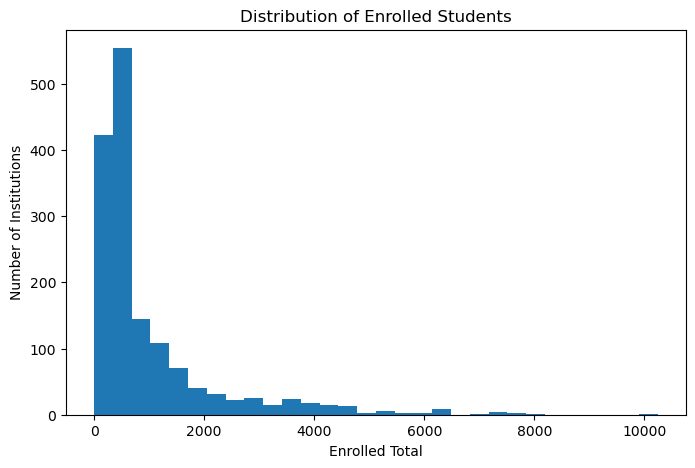

In [20]:
# 1. Enrollment Distribution
plt.figure(figsize=(8,5))
plt.hist(dataset["Enrolled total"], bins=30)
plt.xlabel("Enrolled Total")
plt.ylabel("Number of Institutions")
plt.title("Distribution of Enrolled Students")
plt.show()

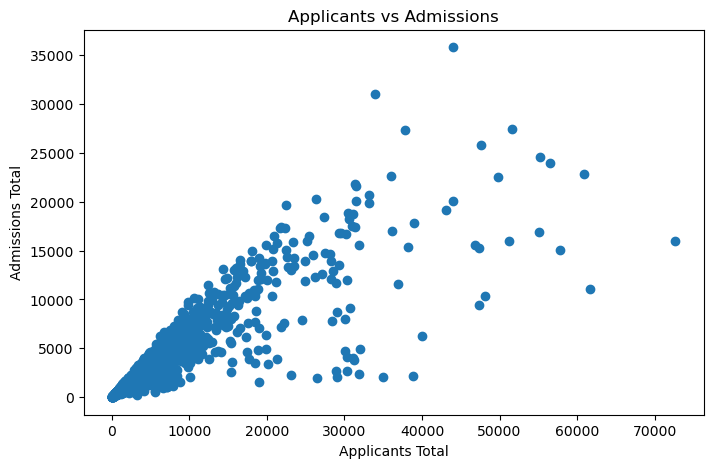

In [21]:
# 2. Applicants vs Admissions
plt.figure(figsize=(8,5))
plt.scatter(dataset["Applicants total"], dataset["Admissions total"])
plt.xlabel("Applicants Total")
plt.ylabel("Admissions Total")
plt.title("Applicants vs Admissions")
plt.show()

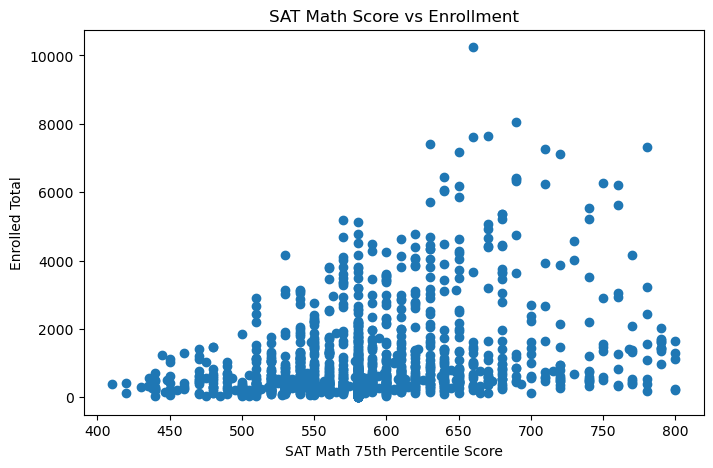

In [22]:
# 3. SAT Math 75th Percentile vs Enrollment
plt.figure(figsize=(8,5))
plt.scatter(dataset["SAT Math 75th percentile score"], dataset["Enrolled total"])
plt.xlabel("SAT Math 75th Percentile Score")
plt.ylabel("Enrolled Total")
plt.title("SAT Math Score vs Enrollment")
plt.show()

<Figure size 800x500 with 0 Axes>

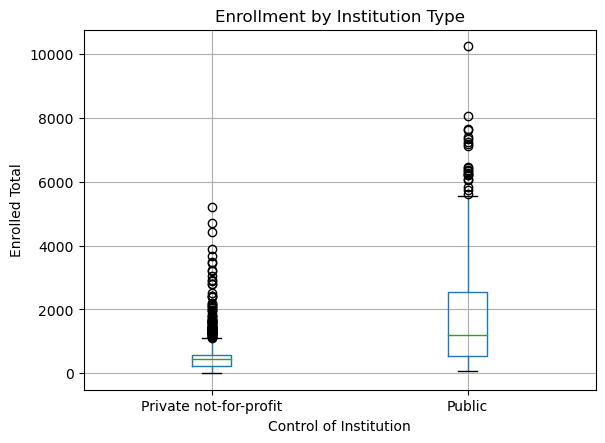

In [23]:
# 4. Public vs Private Enrollment
plt.figure(figsize=(8,5))
dataset.boxplot(column="Enrolled total", by="Control of institution")
plt.xlabel("Control of Institution")
plt.ylabel("Enrolled Total")
plt.title("Enrollment by Institution Type")
plt.suptitle("")
plt.show()

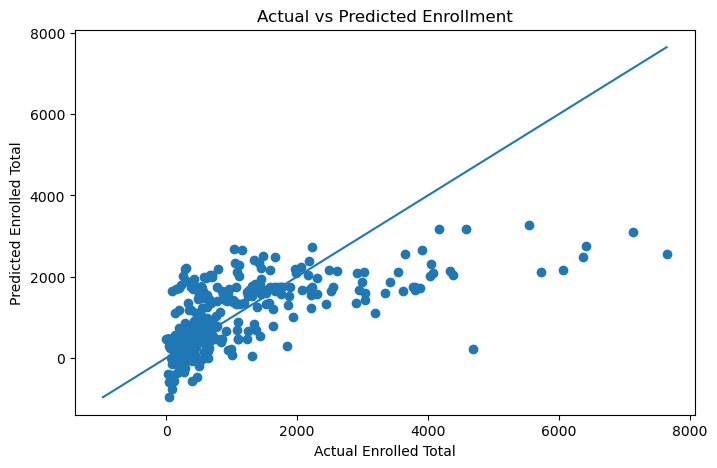

In [24]:
# 5. Actual vs Predicted Enrollment
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred_mlr)
plt.xlabel("Actual Enrolled Total")
plt.ylabel("Predicted Enrolled Total")
plt.title("Actual vs Predicted Enrollment")

# Reference line
min_val = min(y_test.min(), y_pred_mlr.min())
max_val = max(y_test.max(), y_pred_mlr.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.show()

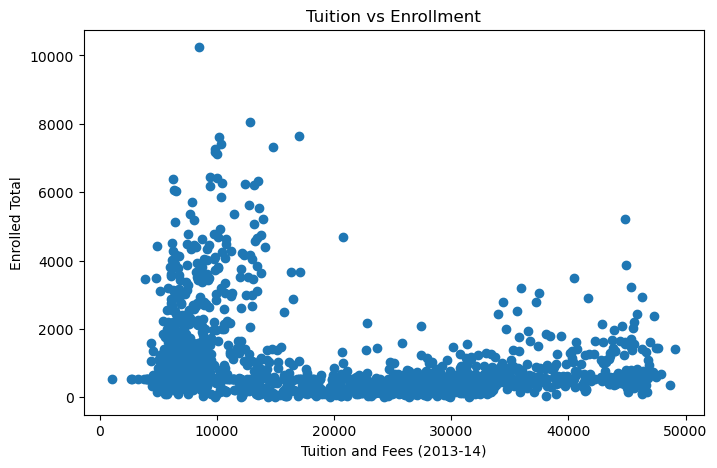

In [25]:
# 6. Tuition vs Enrollment
plt.figure(figsize=(8,5))
plt.scatter(dataset["Tuition and fees, 2013-14"], dataset["Enrolled total"])
plt.xlabel("Tuition and Fees (2013-14)")
plt.ylabel("Enrolled Total")
plt.title("Tuition vs Enrollment")
plt.show()

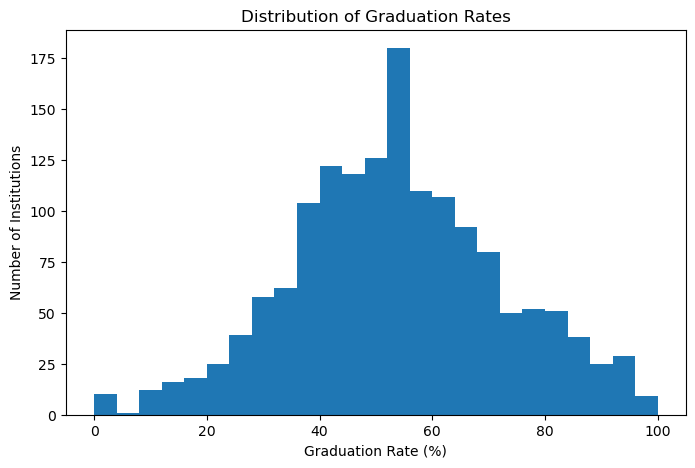

In [26]:
# 7. Graduation Rate Distribution
plt.figure(figsize=(8,5))
plt.hist(dataset["Graduation rate - Bachelor degree within 6 years, total"], bins=25)
plt.xlabel("Graduation Rate (%)")
plt.ylabel("Number of Institutions")
plt.title("Distribution of Graduation Rates")
plt.show()

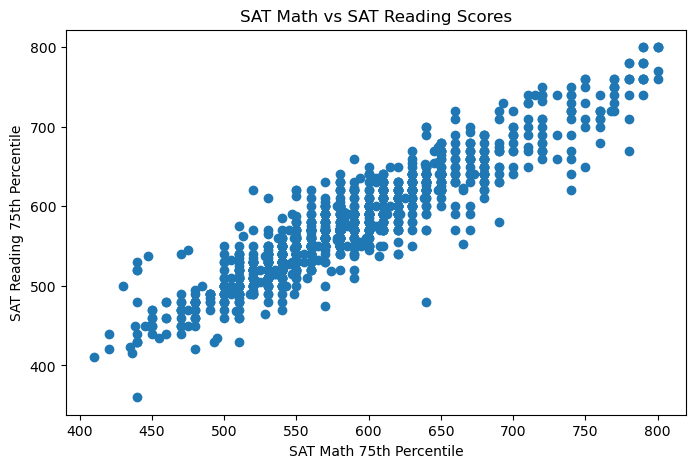

In [27]:
# 8. SAT Math vs SAT Reading
plt.figure(figsize=(8,5))
plt.scatter(
    dataset["SAT Math 75th percentile score"],
    dataset["SAT Critical Reading 75th percentile score"]
)
plt.xlabel("SAT Math 75th Percentile")
plt.ylabel("SAT Reading 75th Percentile")
plt.title("SAT Math vs SAT Reading Scores")
plt.show()